# Performance Attribution (Brinson-Fachler)

## Why this matters

After delivering a portfolio's return, an AM must explain **why** — what drove the result vs the benchmark. **Brinson-Fachler attribution** decomposes active return into:

- **Allocation** (over/underweighting sectors vs benchmark)
- **Selection** (picking better/worse stocks within each sector)
- **Interaction** (cross-effect)

You will be asked, in any AM interview:
1. State the BHB / BF formula.
2. Difference between **arithmetic** and **geometric** attribution.
3. Multi-period attribution issues.
4. Currency attribution for international portfolios.
5. Karnosky-Singer for currency-overlay decomposition.

This notebook covers the BF basics on a 5-sector portfolio.

## Brinson-Fachler formula

For sector $i$, let:
- $w_i^P, w_i^B$: portfolio and benchmark weight
- $r_i^P, r_i^B$: portfolio and benchmark return in sector $i$

Active return decomposes:

$$R^P - R^B = \sum_i \big[\underbrace{(w_i^P - w_i^B)(r_i^B - R^B)}_{\text{Allocation}} + \underbrace{w_i^B (r_i^P - r_i^B)}_{\text{Selection}} + \underbrace{(w_i^P - w_i^B)(r_i^P - r_i^B)}_{\text{Interaction}}\big]$$

(Brinson-Hood-Beebower has slightly different formulation; BF subtracts $R^B$ in the allocation term.)

Each term tells a different story:
- **Allocation**: "did I pick the right *sectors*?"
- **Selection**: "did I pick the right *stocks within sectors*?"
- **Interaction**: cross-effect; usually small but accounting for it makes the decomposition exact.

## Setup — synthetic portfolio + benchmark

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 5-sector portfolio
sectors = ['Tech', 'Financials', 'Healthcare', 'Consumer', 'Energy']

# Weights
w_p = np.array([0.40, 0.10, 0.20, 0.20, 0.10])   # Portfolio (overweight tech)
w_b = np.array([0.30, 0.20, 0.20, 0.20, 0.10])   # Benchmark

# Sector returns over the period
r_p = np.array([0.18, 0.05, 0.10, 0.06, -0.05])   # Portfolio sector returns
r_b = np.array([0.15, 0.06, 0.09, 0.07, -0.04])   # Benchmark sector returns

R_p = w_p @ r_p
R_b = w_b @ r_b
active = R_p - R_b

print(f'{"Sector":>12}  {"w_P":>6}  {"w_B":>6}  {"r_P":>6}  {"r_B":>6}')
for s, wp, wb, rp, rb in zip(sectors, w_p, w_b, r_p, r_b):
    print(f'{s:>12}  {wp:>6.2%}  {wb:>6.2%}  {rp:>+6.2%}  {rb:>+6.2%}')

print(f'\nPortfolio return:  {R_p:+.4%}')
print(f'Benchmark return:  {R_b:+.4%}')
print(f'Active return:     {active:+.4%}')

      Sector     w_P     w_B     r_P     r_B
        Tech  40.00%  30.00%  +18.00%  +15.00%
  Financials  10.00%  20.00%  +5.00%  +6.00%
  Healthcare  20.00%  20.00%  +10.00%  +9.00%
    Consumer  20.00%  20.00%  +6.00%  +7.00%
      Energy  10.00%  10.00%  -5.00%  -4.00%

Portfolio return:  +10.4000%
Benchmark return:  +8.5000%
Active return:     +1.9000%


## Brinson-Fachler decomposition

In [2]:
allocation = (w_p - w_b) * (r_b - R_b)
selection  = w_b * (r_p - r_b)
interaction = (w_p - w_b) * (r_p - r_b)

attribution = pd.DataFrame({
    'Sector': sectors,
    'w_P': w_p, 'w_B': w_b,
    'r_P': r_p, 'r_B': r_b,
    'Allocation':  allocation,
    'Selection':   selection,
    'Interaction': interaction,
    'Total':       allocation + selection + interaction,
})

print('\nBF attribution (per sector):')
print(attribution.round(4).to_string(index=False))

print(f'\nTotal Allocation:   {allocation.sum():+.4%}')
print(f'Total Selection:    {selection.sum():+.4%}')
print(f'Total Interaction:  {interaction.sum():+.4%}')
print(f'Sum (= active):     {(allocation + selection + interaction).sum():+.4%}')
print(f'Active (check):     {active:+.4%}')


BF attribution (per sector):
    Sector  w_P  w_B   r_P   r_B  Allocation  Selection  Interaction   Total
      Tech  0.4  0.3  0.18  0.15      0.0065      0.009        0.003  0.0185
Financials  0.1  0.2  0.05  0.06      0.0025     -0.002        0.001  0.0015
Healthcare  0.2  0.2  0.10  0.09      0.0000      0.002        0.000  0.0020
  Consumer  0.2  0.2  0.06  0.07     -0.0000     -0.002       -0.000 -0.0020
    Energy  0.1  0.1 -0.05 -0.04     -0.0000     -0.001       -0.000 -0.0010

Total Allocation:   +0.9000%
Total Selection:    +0.6000%
Total Interaction:  +0.4000%
Sum (= active):     +1.9000%
Active (check):     +1.9000%


## Visualisation

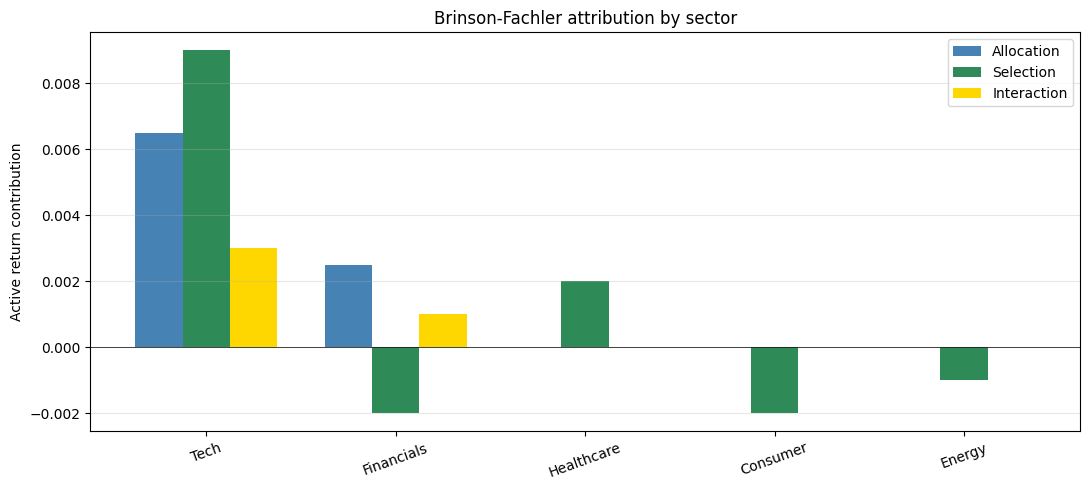

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(sectors))
width = 0.25
ax.bar(x - width, allocation, width, label='Allocation', color='steelblue')
ax.bar(x,         selection,  width, label='Selection',  color='seagreen')
ax.bar(x + width, interaction, width, label='Interaction', color='gold')
ax.set_xticks(x); ax.set_xticklabels(sectors, rotation=20)
ax.set_ylabel('Active return contribution')
ax.set_title('Brinson-Fachler attribution by sector')
ax.axhline(0, color='black', lw=0.5)
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Multi-period attribution

Attribution at one period is exact. Across multiple periods, the components don't simply sum because of compounding. Two main resolutions:

1. **Arithmetic carry-forward**: Compute attribution per period; sum each component over time. Doesn't equal the geometric multi-period active return exactly. Standard in **GIPS-compliant reports**.
2. **Carino linking** / **Menchero smoothing**: scale per-period contributions by a factor that makes them sum to total geometric active return.

For interview prep, focus on the **single-period BF** decomposition and explain that multi-period requires a linking method (Carino is most common).

## Exercises

### Exercise 1 — BHB vs BF

Brinson-Hood-Beebower (1986) uses Allocation = $(w_i^P - w_i^B) r_i^B$ instead of $(w_i^P - w_i^B)(r_i^B - R^B)$. Compute both for our example and explain the difference.

In [4]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
alloc_bhb = (w_p - w_b) * r_b
alloc_bf  = (w_p - w_b) * (r_b - R_b)
print(f'Allocation (BHB): {alloc_bhb.sum():+.4%}')
print(f'Allocation (BF):  {alloc_bf.sum():+.4%}')
print('→ BHB allocates against benchmark sector return alone.')
print('→ BF allocates against benchmark sector EXCESS return (vs total benchmark).')
print('→ BF is preferred when overweight/underweight should reflect *outperforming* sectors.')
```

_Both are valid; BF is more common today._

</details>

### Exercise 2 — Pure stock-picker portfolio

Set $w_P = w_B$ (same sector weights as benchmark, only stock-picking matters). Verify Allocation = 0 and active = Selection + Interaction.

In [5]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
w_p_test = w_b.copy()
alloc = (w_p_test - w_b) * (r_b - R_b)
sel = w_b * (r_p - r_b)
intr = (w_p_test - w_b) * (r_p - r_b)
print(f'Allocation (should be 0):     {alloc.sum():+.4%}')
print(f'Selection:                     {sel.sum():+.4%}')
print(f'Interaction (should be 0):    {intr.sum():+.4%}')
```

_When sector weights match benchmark, only stock selection drives active return._

</details>

## Interview Q&A

**Q: State the BF decomposition.**

A: Active = Allocation + Selection + Interaction. Allocation = $(w^P - w^B)(r^B - R^B)$. Selection = $w^B(r^P - r^B)$. Interaction = $(w^P - w^B)(r^P - r^B)$. Sum across sectors.

**Q: When does Allocation contribute positively?**

A: Overweight a sector that beat the benchmark, or underweight a sector that underperformed. The product $(w^P - w^B)(r^B - R^B)$ is positive in either case.

**Q: BHB vs BF?**

A: BHB allocation = $(w^P - w^B) r^B$. BF allocation = $(w^P - w^B)(r^B - R^B)$. BF subtracts the total benchmark, so allocation reflects **excess** sector performance, not just absolute. BF is the modern default; BHB is the original.

**Q: What's the interaction term?**

A: The cross-effect when you both *overweighted* AND *picked good stocks*. It's symmetric in (w-w) and (r-r). Often small. Some report Allocation+Interaction together (combined as "active allocation") to simplify.

**Q: Currency attribution?**

A: For international portfolios, decompose currency effect separately. **Karnosky-Singer (1994)** handles allocation, selection, and currency cleanly via a multi-currency framework. Standard reference for global mandates.

## Pitfalls

| Pitfall | Issue | Fix |
|---|---|---|
| Multi-period summing | Per-period components don't compound to total active | Carino linking |
| Wrong reference benchmark | Active return depends critically on the right benchmark | Match the mandate exactly |
| Sector definitions | Different providers use different sector taxonomies (GICS vs ICB) | State which |
| Single-currency assumption | International portfolios need currency component | Karnosky-Singer |
| Look-through for funds | Multi-asset / fund-of-funds requires drilling down | Need underlying holdings |

## What you've earned

After this notebook you can apply Brinson-Fachler to any portfolio with sector data, decompose active return into allocation/selection/interaction, distinguish from BHB, and explain the multi-period and currency complications. Standard for any AM portfolio review meeting.